In [35]:
from torch.utils.data import Dataset
import os.path as osp
from os import listdir
import pandas as pd

In [45]:
path = r"C:\Users\peter\Repos\ENFIELD-data\processed_unpack\nwp_0h"
country = "Slovakia"
split = "train"
installation = "random"

country_folder = osp.join(path, country)
metadata = pd.read_csv(osp.join(country_folder, "metadata.csv"))

In [47]:
metadata["Total Records"] = metadata["Number of records 2020"] + metadata["Number of records 2021"] + metadata["Number of records 2022"] + metadata["Number of records 2023"]
metadata = metadata.sort_values("Total Records", ascending=False)
metadata["System ID"].iloc[0]

np.int64(74482)

In [48]:
metadata.head()

,System ID,System Size (watts),Postcode / Zipcode,Panels,Panel Power (watts),Panel Brand,Inverters,Inverter Power (watts),Inverter Brand,Orientation,...,Import Off Peak Tariff,Import Shoulder Tariff,Import High Shoulder Tariff,Import Daily Charge,Elevation,Number of records 2020,Number of records 2021,Number of records 2022,Number of records 2023,Total Records
29,74482,9780,NaN,15,360,SunEnergy + CanadianSolar,2,10000,2x PIP5048MK + MPPT 150/70,SE,...,17.0,NaN,NaN,NaN,217.400314,249,358,302,307,1216
5,62495,4020,NaN,12,335,LG335N1C-A5,1,4800,Fronius Symo 4.5.3,S,...,NaN,NaN,NaN,NaN,130.752167,274,334,280,285,1173
43,73412,15840,NaN,48,330,Trina,3,5000,MPP,EW,...,NaN,NaN,NaN,NaN,438.456665,217,346,289,303,1155
10,65752,2000,NaN,8,250,???,1,2000,Growatt,S,...,NaN,NaN,NaN,NaN,186.797028,272,330,274,263,1139
13,68792,3000,NaN,12,250,Unknown,1,3000,Effekta,E,...,NaN,NaN,NaN,NaN,162.575806,240,310,276,289,1115


In [52]:
installation_folder = osp.join(country_folder, str(metadata["System ID"].iloc[0]))
installation_folder

'C:\\Users\\peter\\Repos\\ENFIELD-data\\processed_unpack\\nwp_0h\\Slovakia\\74482'

In [55]:
samples = listdir(installation_folder)
test_samples = samples[-len(samples)//5:]
train_samples_full = samples[:-len(samples)//5]
valid_samples = train_samples_full[::8]
train_samples = list(set(train_samples_full) - set(valid_samples))

In [57]:
print(f"Total samples: {len(samples)}")
print(f"Training samples: {len(train_samples)}")
print(f"Validation samples: {len(valid_samples)}")
print(f"Testing samples: {len(test_samples)}")

Total samples: 1216
Training samples: 850
Validation samples: 122
Testing samples: 244


In [1]:
import os
os.chdir("./..")

from PVDataset import PVDataset

ds = PVDataset(r"C:\Users\peter\Repos\ENFIELD-data\processed_unpack\nwp_0h", "Germany", "top", "train")

In [2]:
ds.installation_metadata

System ID                                   66895
System Size (watts)                          9610
Postcode / Zipcode                            NaN
Panels                                         31
Panel Power (watts)                           310
Panel Brand                      IBC MonoSo1310VL
Inverters                                       1
Inverter Power (watts)                      10000
Inverter Brand                            Fronius
Orientation                                     S
Array Tilt (degrees)                          1.0
Shade                                          No
Install Date                           20190314.0
Latitude                                51.960372
Longitude                                7.994981
Status Interval (minutes)                       5
Secondary Panels                                0
Secondary Panel Power (watts)                   0
Secondary Orientation                         NaN
Secondary Array Tilt                          NaN


In [2]:
x, y, metadata = ds[0]

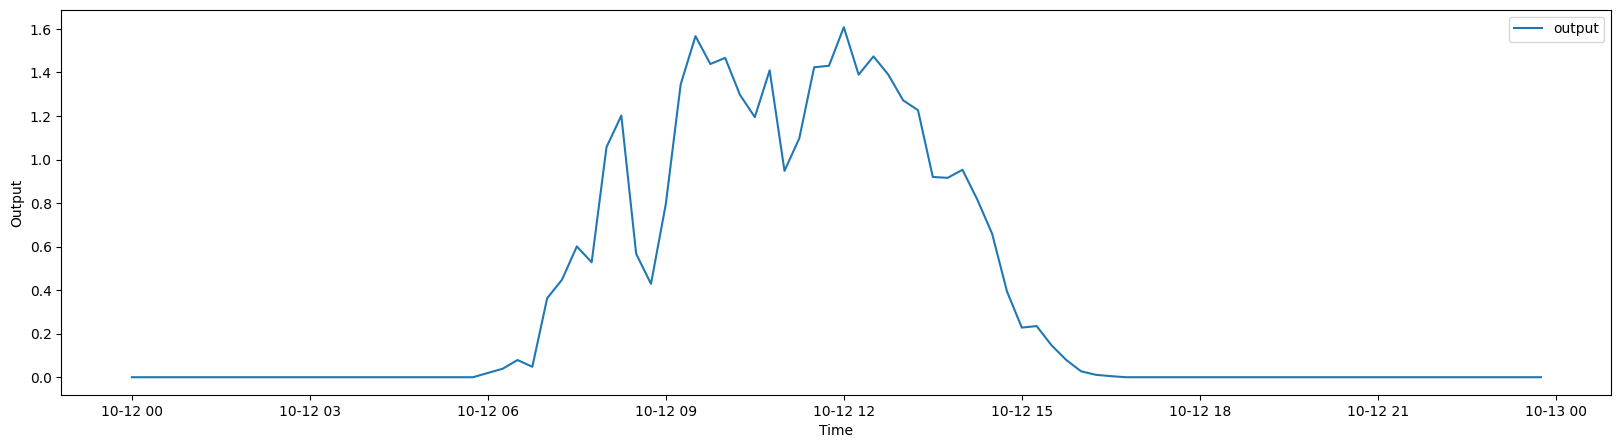

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

import random 

x, y, metadata = ds[random.randint(0, len(ds)-1)]

fig, ax = plt.subplots(1, 1, figsize=(20, 5))
ax.plot(pd.to_datetime(x[-1], unit="s"), y, label="output")
ax.set_xlabel("Time")
ax.set_ylabel("Output")
ax.legend()
plt.show()

In [6]:
import torch

total = torch.zeros(96)

for i in range(len(ds)):
    x, y, metadata = ds[i]
    total += y

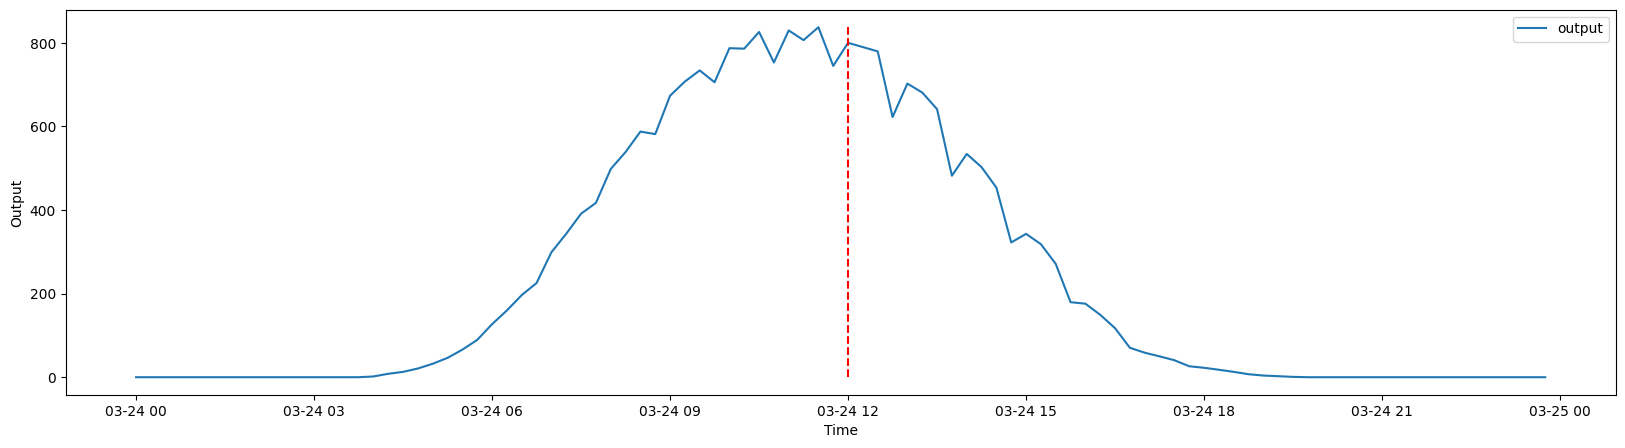

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(20, 5))
ax.plot(pd.to_datetime(x[-1], unit="s"), total, label="output")
ax.set_xlabel("Time")
ax.set_ylabel("Output")
ax.legend()
ax.vlines(pd.to_datetime(x[-1], unit="s")[(12*4)], ymin=0, ymax=total.max(), colors="red", linestyles="dashed")
plt.show()

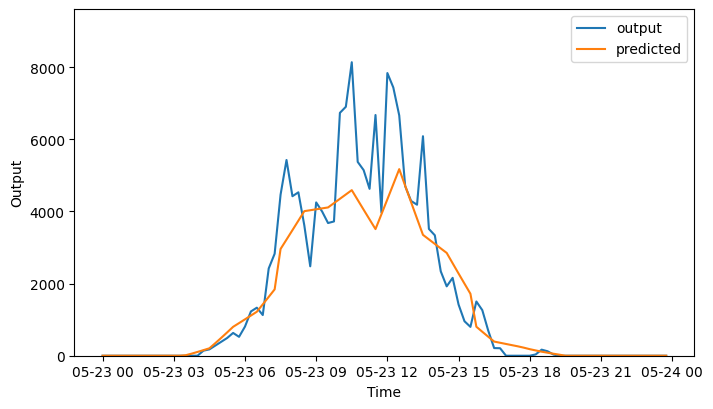

In [59]:
from models.ADRInspired import ADRInspired as ADR
from utils.config import load_config
import torch
import matplotlib.pyplot as plt
import pandas as pd

import random 

config = load_config("./config/ADR.yaml")
model = ADR(config)

x, y, metadata = ds[random.randint(0, len(ds)-1)]
metadata_tensors = {}
for k, v in metadata.items():
    try:
        metadata_tensors[k] = torch.tensor(v).unsqueeze(0)
    except (TypeError, ValueError):
        metadata_tensors[k] = [v]

y_hat = model([t.unsqueeze(0) for t in x], metadata_tensors)
predicted = y_hat.detach().numpy()

fig, ax = plt.subplots(1, 1, figsize=(8, 4.5))
ax.plot(pd.to_datetime(x[-1], unit="s"), y*4000, label="output")
ax.plot(pd.to_datetime(x[-1], unit="s"), predicted[0], label="predicted")
ax.set_xlabel("Time")
ax.set_ylabel("Output")
ax.legend()
ax.set_ylim(0,9610)
plt.show()